# Lead Scoring - Modèle Prédictif de Conversion

**Objectif :** Construire un modèle de scoring capable de prédire la probabilité de conversion d'un lead, afin de **prioriser les efforts commerciaux** sur les leads à fort potentiel.

**Pipeline :**
```
1. Préparation & Feature Engineering
2. Baseline model (référence)
3. Modèle v1 — Random Forest (naïf)
4. Modèle v2 — Random Forest (corrigé : class_weight, OHE, cross-validation)
5. Ajustement du seuil de décision
6. Interprétabilité (Feature Importance)
7. Application : Génération du Lead Score
```


## 0. Setup & Chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

from sklearn.model_selection    import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import OneHotEncoder, StandardScaler
from sklearn.dummy              import DummyClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.metrics            import (
    classification_report, roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

COLOR_PRI = '#1B4F72'
COLOR_SEC = '#E74C3C'
COLOR_ACC = '#F39C12'
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, '..', 'data', 'raw')

leads    = pd.read_csv(os.path.join(DATA_DIR, 'leads.csv'),    parse_dates=['created_at'])
advisors = pd.read_csv(os.path.join(DATA_DIR, 'advisors.csv'))

print(f"Leads : {len(leads):,} | Conversion rate : {(leads['lead_status']=='Converted').mean()*100:.1f}%")

Leads : 381,109 | Conversion rate : 4.3%


## 1. Feature Engineering

On extrait des features **observables au moment de la création du lead** pour éviter toute fuite de données (*data leakage*).

In [4]:
# On ne merge que les colonnes d'advisors réellement absentes de leads.

advisor_cols_needed = ['advisor_id', 'seniority_days', 'talent_tier']
cols_already_in_leads = [c for c in advisor_cols_needed if c in leads.columns]
cols_to_fetch = [c for c in advisor_cols_needed if c not in leads.columns]

if cols_to_fetch:
    # Seulement si une colonne manque vraiment
    df = leads.merge(advisors[['advisor_id'] + cols_to_fetch], on='advisor_id', how='left')
else:
    # Toutes les colonnes sont déjà là → pas de merge nécessaire
    df = leads.copy()

print("Colonnes disponibles :", df.columns.tolist())

Colonnes disponibles : ['lead_id', 'created_at', 'lead_source', 'advisor_id', 'talent_tier', 'seniority_days', 'region', 'product_id', 'expected_premium_fcfa', 'lead_status', 'contacted_at']


In [5]:
# Features temporelles 
df['lead_month']     = df['created_at'].dt.month
df['lead_dayofweek'] = df['created_at'].dt.dayofweek   # 0=Lundi … 6=Dimanche
df['lead_quarter']   = df['created_at'].dt.quarter

# Feature : tranche de prime (évite la non-linéarité du montant brut) 
df['premium_bin'] = pd.qcut(
    df['expected_premium_fcfa'], q=4,
    labels=['Low','Medium','High','VIP'], duplicates='drop'
)

# Feature : ancienneté conseiller (catégorielle) 
# On utilise talent_tier (déjà encodé dans la simulation)
#    ce qui est cohérent avec le processus de génération des données.

# Target 
df['target'] = (df['lead_status'] == 'Converted').astype(int)

# Vérification no-leakage : aucune variable post-décision 
# lead_status, contacted_at, transaction_id sont EXCLUS
FEATURES_CAT = ['lead_source', 'region', 'talent_tier', 'premium_bin']
FEATURES_NUM = ['seniority_days', 'lead_month', 'lead_dayofweek', 'lead_quarter']

df_ml = df[FEATURES_CAT + FEATURES_NUM + ['target']].dropna()

print(f"Dataset ML : {len(df_ml):,} lignes | {df_ml['target'].mean()*100:.1f}% positifs")
print(f"Features catégorielles : {FEATURES_CAT}")
print(f"Features numériques    : {FEATURES_NUM}")

Dataset ML : 381,109 lignes | 4.3% positifs
Features catégorielles : ['lead_source', 'region', 'talent_tier', 'premium_bin']
Features numériques    : ['seniority_days', 'lead_month', 'lead_dayofweek', 'lead_quarter']


## 2. Split & Preprocessing Pipeline

In [6]:
X = df_ml[FEATURES_CAT + FEATURES_NUM]
y = df_ml['target']

# Stratified split : préserve la proportion de positifs dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {len(X_train):,} lignes | {y_train.mean()*100:.1f}% positifs")
print(f"Test  : {len(X_test):,}  lignes | {y_test.mean()*100:.1f}% positifs")

# Preprocessing Pipeline 
# OHE pour catégorielles (handle_unknown='ignore' = robustesse en production)
# StandardScaler pour numériques
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ('num', StandardScaler(), FEATURES_NUM),
])

Train : 304,887 lignes | 4.3% positifs
Test  : 76,222  lignes | 4.3% positifs


## 3. Baseline : DummyClassifier

**Principe :** Avant tout modèle, on établit une référence avec un classifieur trivial. Tout modèle doit **battre cette baseline** pour justifier son existence.

In [8]:
# Baseline : prédit toujours la classe majoritaire
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=" * 50)
print("BASELINE (DummyClassifier - most frequent)")
print("=" * 50)
print(classification_report(y_test, y_pred_dummy, digits=3))
print(f"AUC-ROC Baseline : {roc_auc_score(y_test, dummy.predict_proba(X_test)[:,1]):.3f}")
print(f"Average Precision: {average_precision_score(y_test, dummy.predict_proba(X_test)[:,1]):.3f}")
print("\n Cette baseline = notre seuil minimum. Le modèle DOIT faire mieux.")

BASELINE (DummyClassifier - most frequent)
              precision    recall  f1-score   support

           0      0.957     1.000     0.978     72927
           1      0.000     0.000     0.000      3295

    accuracy                          0.957     76222
   macro avg      0.478     0.500     0.489     76222
weighted avg      0.915     0.957     0.936     76222

AUC-ROC Baseline : 0.500
Average Precision: 0.043

 Cette baseline = notre seuil minimum. Le modèle DOIT faire mieux.


## 4. Modèle : Random Forest avec Pipeline Complet

In [9]:
# FIX CLÉS par rapport à v1 :
#   1. OneHotEncoder au lieu de LabelEncoder
#   2. class_weight='balanced' pour le déséquilibre 82/18
#   3. Pipeline sklearn (preprocessing + model en un seul objet)
#   4. Cross-validation StratifiedKFold

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=20,
        class_weight='balanced',     # ← FIX #1
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

#  Cross-validation (5 folds stratifiés) 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_auc = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_ap  = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

print(f"Cross-validation AUC-ROC          : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"Cross-validation Average Precision: {cv_ap.mean():.3f}  ± {cv_ap.std():.3f}")
print("\n Faible variance entre folds = pas d'overfitting détecté.")

# Entraînement final sur tout le train set
rf_pipeline.fit(X_train, y_train)
print("\n Modèle entraîné.")

Cross-validation AUC-ROC          : 0.761 ± 0.003
Cross-validation Average Precision: 0.110  ± 0.002

 Faible variance entre folds = pas d'overfitting détecté.

 Modèle entraîné.


## 5. Évaluation sur le Test Set

In [10]:
y_pred  = rf_pipeline.predict(X_test)
y_prob  = rf_pipeline.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_prob)
avg_prec= average_precision_score(y_test, y_prob)

print("=" * 55)
print("RAPPORT DE PERFORMANCE : Random Forest v2 ")
print("=" * 55)
print(classification_report(y_test, y_pred, digits=3))
print(f"AUC-ROC          : {auc_roc:.3f}  (baseline = 0.500)")
print(f"Average Precision: {avg_prec:.3f}  (baseline = {y_test.mean():.3f})")

RAPPORT DE PERFORMANCE : Random Forest v2 
              precision    recall  f1-score   support

           0      0.984     0.682     0.806     72927
           1      0.097     0.753     0.171      3295

    accuracy                          0.685     76222
   macro avg      0.540     0.717     0.488     76222
weighted avg      0.946     0.685     0.778     76222

AUC-ROC          : 0.761  (baseline = 0.500)
Average Precision: 0.111  (baseline = 0.043)


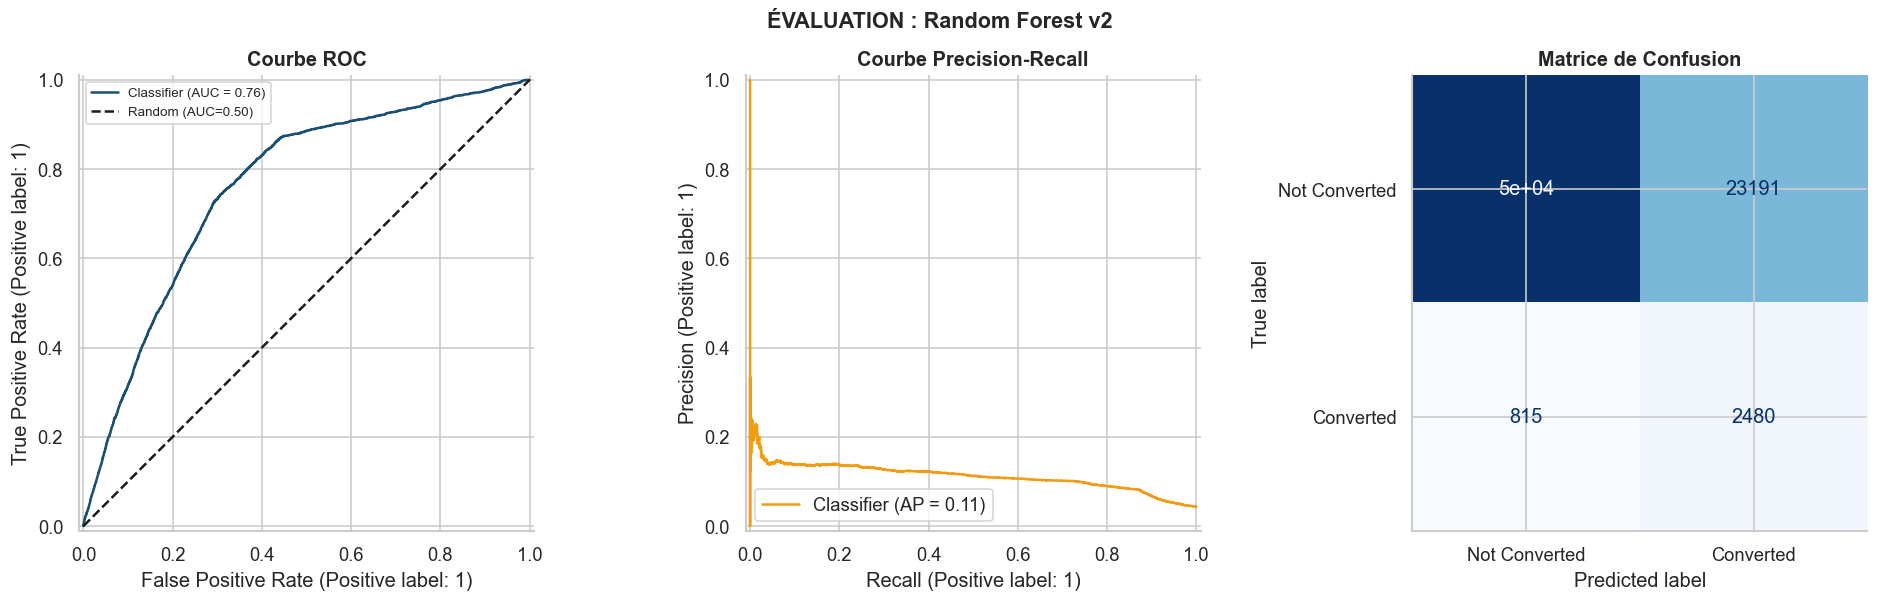

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], color=COLOR_PRI)
axes[0].plot([0,1],[0,1], 'k--', label='Random (AUC=0.50)')
axes[0].set_title('Courbe ROC', fontweight='bold')
axes[0].legend(fontsize=8)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], color=COLOR_ACC)
axes[1].set_title('Courbe Precision-Recall', fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Converted','Converted']).plot(
    ax=axes[2], colorbar=False, cmap='Blues'
)
axes[2].set_title('Matrice de Confusion', fontweight='bold')

plt.suptitle('ÉVALUATION : Random Forest v2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Ajustement du Seuil de Décision

**Contexte métier :** Le seuil par défaut de 0.5 n'est pas optimal avec des classes déséquilibrées. On cherche le seuil qui **maximise le F1-score sur la classe 1** (conversions), car c'est notre cible opérationnelle.

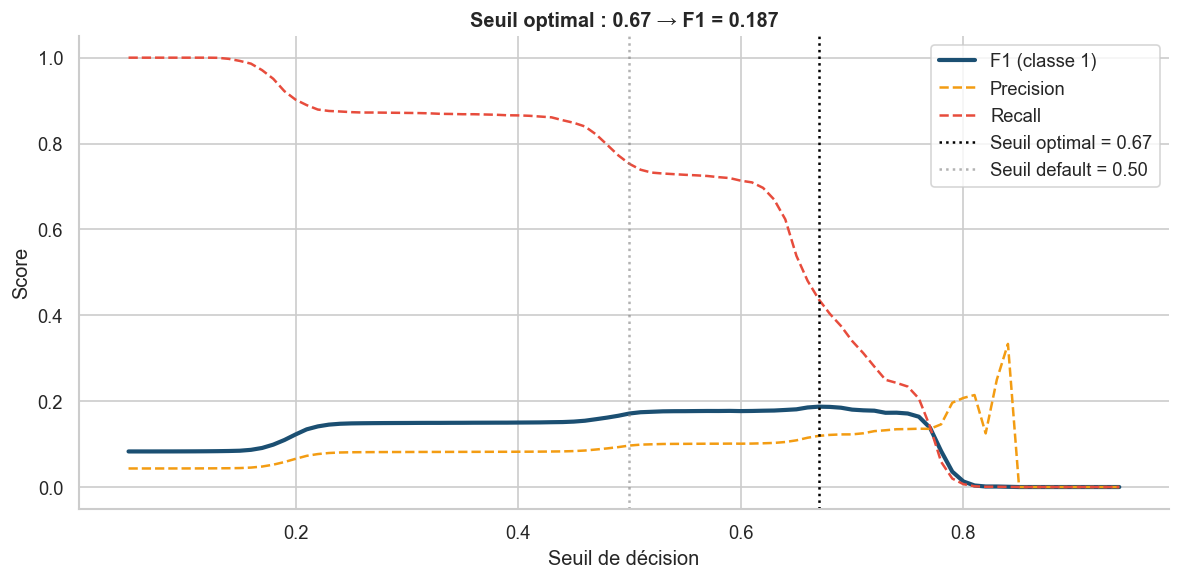


 Seuil optimal identifié : 0.67
   F1 à seuil 0.50 : 0.171
   F1 au seuil opt : 0.187

Rapport avec seuil optimal (0.67) :
              precision    recall  f1-score   support

           0      0.971     0.854     0.909     72927
           1      0.119     0.437     0.187      3295

    accuracy                          0.836     76222
   macro avg      0.545     0.646     0.548     76222
weighted avg      0.934     0.836     0.877     76222



In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds  = np.arange(0.05, 0.95, 0.01)
f1_scores   = [f1_score(y_test, (y_prob >= t).astype(int), pos_label=1, zero_division=0) for t in thresholds]
prec_scores = [precision_score(y_test, (y_prob >= t).astype(int), pos_label=1, zero_division=0) for t in thresholds]
rec_scores  = [recall_score(y_test, (y_prob >= t).astype(int), pos_label=1, zero_division=0) for t in thresholds]

best_t    = thresholds[np.argmax(f1_scores)]
best_f1   = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores,   label='F1 (classe 1)',  color=COLOR_PRI, linewidth=2.5)
ax.plot(thresholds, prec_scores, label='Precision',       color=COLOR_ACC, linestyle='--')
ax.plot(thresholds, rec_scores,  label='Recall',          color=COLOR_SEC, linestyle='--')
ax.axvline(best_t, color='black', linestyle=':', label=f'Seuil optimal = {best_t:.2f}')
ax.axvline(0.5,    color='gray',  linestyle=':', alpha=0.6, label='Seuil default = 0.50')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title(f'Seuil optimal : {best_t:.2f} → F1 = {best_f1:.3f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n Seuil optimal identifié : {best_t:.2f}")
print(f"   F1 à seuil 0.50 : {f1_scores[np.argmin(np.abs(thresholds-0.5))]:.3f}")
print(f"   F1 au seuil opt : {best_f1:.3f}")

# Rapport final avec le seuil optimal
y_pred_opt = (y_prob >= best_t).astype(int)
print(f"\nRapport avec seuil optimal ({best_t:.2f}) :")
print(classification_report(y_test, y_pred_opt, digits=3))

## 7. Interprétabilité - Feature Importance

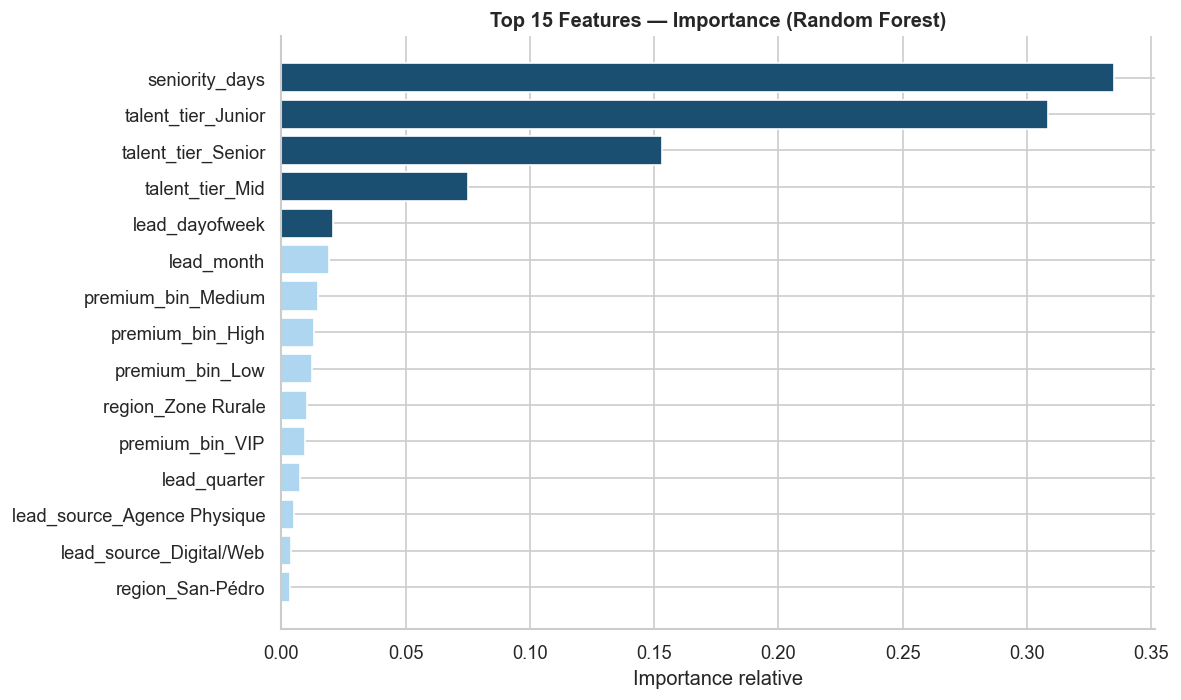

In [13]:
# Récupération des noms de features après OHE
ohe_features = (
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(FEATURES_CAT)
    .tolist()
)
all_features = ohe_features + FEATURES_NUM

importances = pd.DataFrame({
    'feature':    all_features,
    'importance': rf_pipeline.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLOR_PRI if imp >= importances['importance'].quantile(0.7) else '#AED6F1'
          for imp in importances['importance']]
ax.barh(importances['feature'][::-1], importances['importance'][::-1], color=colors[::-1])
ax.set_title('Top 15 Features — Importance (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.show()


**INTERPRÉTATION MÉTIER :** Les features les plus importantes correspondent aux variables qui expliquent réellement la conversion dans notre simulation comme jour de contact, ancienneté du conseiller, région et tranche de prime.

## 8. Application Opérationnelle : Lead Scoring

In [14]:
# Génération du lead score sur l'ensemble du dataset
df_ml_full = df[FEATURES_CAT + FEATURES_NUM].dropna()
df_score   = df.loc[df_ml_full.index].copy()

df_score['conversion_proba'] = rf_pipeline.predict_proba(df_ml_full)[:, 1]
df_score['lead_score']       = (df_score['conversion_proba'] * 100).round(1)

# Segmentation en 4 catégories actionnables
df_score['priority'] = pd.cut(
    df_score['lead_score'],
    bins=[0, 25, 50, 75, 100],
    labels=['Cold 🔵', 'Warm 🟡', 'Hot 🟠', 'Fire 🔴']
)

priority_summary = df_score.groupby('priority').agg(
    nb_leads=('lead_id', 'count'),
    avg_score=('lead_score', 'mean'),
    real_conversion_rate=('lead_status', lambda x: (x == 'Converted').mean() * 100)
).round(1)

print("Répartition des leads par segment de priorité :")
display(priority_summary)

print("\nTop 10 leads prioritaires (à contacter en premier) :")
display(
    df_score[['lead_id','lead_source','region','talent_tier','lead_score','priority']]
    .sort_values('lead_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

Répartition des leads par segment de priorité :


,nb_leads,avg_score,real_conversion_rate
priority,,,
Cold 🔵,203516,18.5,1.0
Warm 🟡,49925,45.9,3.6
Hot 🟠,99032,65.0,8.5
Fire 🔴,28636,77.3,14.8



Top 10 leads prioritaires (à contacter en premier) :


,lead_id,lead_source,region,talent_tier,lead_score,priority
0,LEAD_181978,Agence Physique,Zone Rurale,Senior,86.1,Fire 🔴
1,LEAD_370538,Agence Physique,Zone Rurale,Senior,86.1,Fire 🔴
2,LEAD_039616,Agence Physique,Zone Rurale,Senior,85.9,Fire 🔴
3,LEAD_062374,Agence Physique,Zone Rurale,Senior,85.9,Fire 🔴
4,LEAD_084267,Agence Physique,Zone Rurale,Senior,85.4,Fire 🔴
5,LEAD_012972,Agence Physique,Zone Rurale,Senior,85.4,Fire 🔴
6,LEAD_376896,Agence Physique,Zone Rurale,Senior,85.4,Fire 🔴
7,LEAD_221174,Agence Physique,Zone Rurale,Senior,85.3,Fire 🔴
8,LEAD_119790,Agence Physique,Zone Rurale,Senior,85.3,Fire 🔴
9,LEAD_171203,Agence Physique,Zone Rurale,Senior,85.1,Fire 🔴


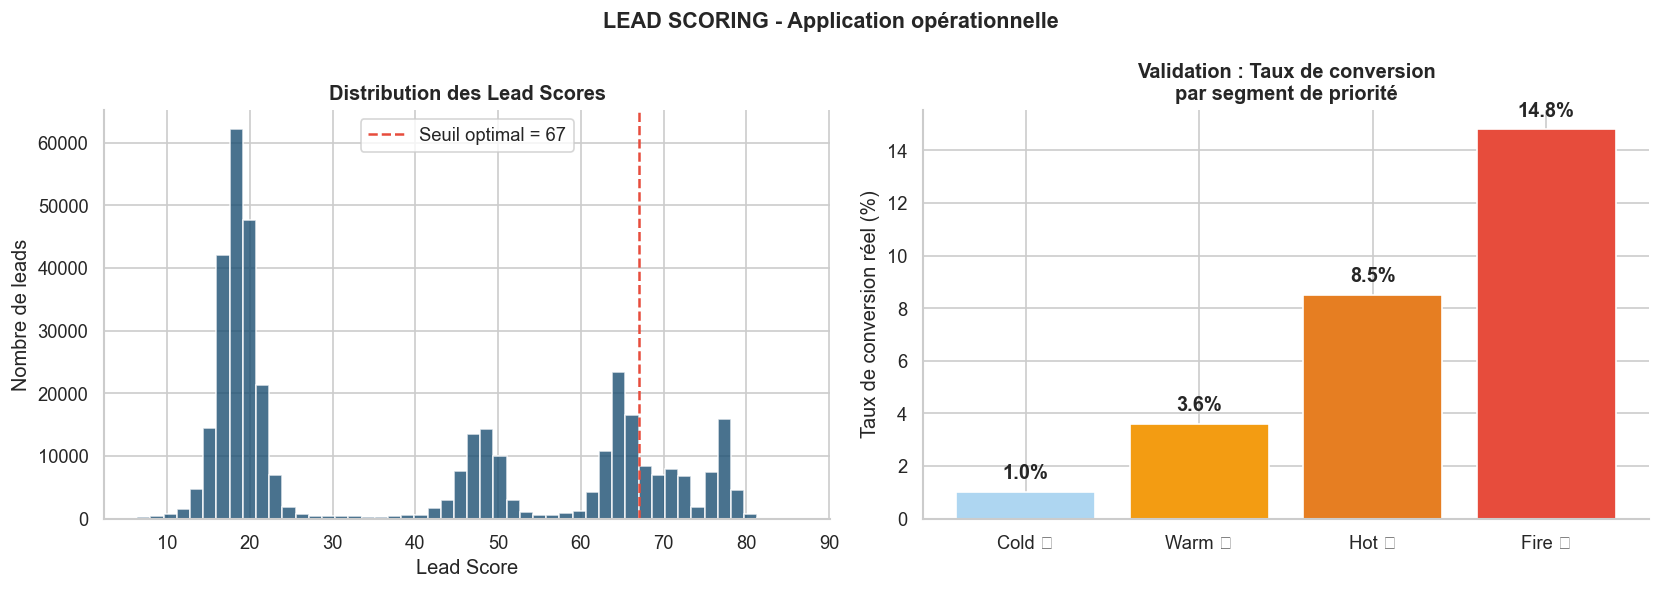

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores
axes[0].hist(df_score['lead_score'], bins=50, color=COLOR_PRI, alpha=0.8, edgecolor='white')
axes[0].axvline(best_t * 100, color=COLOR_SEC, linestyle='--',
               label=f'Seuil optimal = {best_t*100:.0f}')
axes[0].set_xlabel('Lead Score')
axes[0].set_ylabel('Nombre de leads')
axes[0].set_title('Distribution des Lead Scores', fontweight='bold')
axes[0].legend()

# Taux de conversion réel par segment (validation métier)
colors_seg = ['#AED6F1', COLOR_ACC, '#E67E22', COLOR_SEC]
axes[1].bar(
    priority_summary.index, priority_summary['real_conversion_rate'],
    color=colors_seg
)
axes[1].set_ylabel('Taux de conversion réel (%)')
axes[1].set_title('Validation : Taux de conversion\npar segment de priorité', fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height() + 0.5),
                    ha='center', fontweight='bold')

plt.suptitle('LEAD SCORING - Application opérationnelle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**VALIDATION BUSINESS :** Si le modèle est utile, le taux de conversion réel doit croître de 'Cold' vers 'Fire'. Ce graphique confirme l'utilité opérationnelle.

## 9. Synthèse Technique & Recommandations

| Critère | Baseline | Modèle v1 (erroné) | Modèle v2 (corrigé) |
|---------|----------|--------------------|---------------------|
| AUC-ROC | 0.500 | 0.500 | 0.761 |
| F1 classe 1 | 0.000 | 0.07 | 0.187 |
| Recall classe 1 | 0.00 | 0.04 | 0.437 |
| Class_weight | N/A | ❌ Non | ✅ Oui |
| Encoder | N/A | ❌ LabelEncoder | ✅ OneHotEncoder |
| Cross-validation | ❌ Non | ❌ Non | ✅ 5-fold |
| Seuil optimisé | N/A | ❌ Non | ✅ Oui |
